<a href="https://colab.research.google.com/github/uvindu827/J26-DS-350/blob/Indhi_Component2_CHL_Forecast/01_Random_Forest_CHL_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ======================================================================
# STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL
# ======================================================================

import sys
import platform

print("=" * 70)
print("STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL")
print("=" * 70)

print("\nPython version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nRandom Forest training device:")
print("CPU")

STEP 31.9P-12 — RANDOM FOREST BASELINE MODEL

Python version:
3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]

Platform:
Linux-6.6.122+-x86_64-with-glibc2.39

Random Forest training device:
CPU


In [2]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [3]:
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

PREPROCESS_DIR = BASE_DIR / "05_model_preprocessing"

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project directory:")
print(BASE_DIR)

print("\nPreprocessing directory:")
print(PREPROCESS_DIR)

print("\nRandom Forest model directory:")
print(MODEL_DIR)

Project directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data

Preprocessing directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/05_model_preprocessing

Random Forest model directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest


In [4]:
import pandas as pd
import numpy as np

In [5]:
TRAIN_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_train.csv"
)

VALIDATION_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_validation.csv"
)

TEST_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_test.csv"
)

train_df = pd.read_csv(TRAIN_FILE)
validation_df = pd.read_csv(VALIDATION_FILE)
test_df = pd.read_csv(TEST_FILE)

print("=" * 70)
print("MODEL-READY DATASETS LOADED")
print("=" * 70)

print("\nTraining:")
print(train_df.shape)

print("\nValidation:")
print(validation_df.shape)

print("\nTest:")
print(test_df.shape)

MODEL-READY DATASETS LOADED

Training:
(736950, 75)

Validation:
(157896, 75)

Test:
(157998, 75)


In [6]:
FEATURE_FILE = (
    PREPROCESS_DIR /
    "final_model_feature_columns.csv"
)

feature_df = pd.read_csv(FEATURE_FILE)

FEATURES = (
    feature_df["feature"]
    .dropna()
    .astype(str)
    .tolist()
)

FEATURES = list(dict.fromkeys(FEATURES))

print("=" * 70)
print("FINAL MODEL FEATURES")
print("=" * 70)

print("Number of features:", len(FEATURES))

for i, feature in enumerate(FEATURES, start=1):
    print(f"{i:02d}. {feature}")

FINAL MODEL FEATURES
Number of features: 69
01. sst
02. sss
03. nitrate
04. phosphate
05. silicate
06. year
07. month
08. day
09. day_of_year
10. day_of_week
11. week_of_year
12. day_of_year_sin
13. day_of_year_cos
14. month_sin
15. month_cos
16. day_of_week_sin
17. day_of_week_cos
18. chl_lag_1
19. chl_lag_2
20. chl_lag_3
21. chl_lag_5
22. chl_lag_7
23. chl_lag_14
24. chl_lag_30
25. sst_lag_1
26. sst_lag_3
27. sst_lag_7
28. sst_lag_14
29. sss_lag_1
30. sss_lag_3
31. sss_lag_7
32. sss_lag_14
33. nitrate_lag_1
34. nitrate_lag_3
35. nitrate_lag_7
36. nitrate_lag_14
37. phosphate_lag_1
38. phosphate_lag_3
39. phosphate_lag_7
40. phosphate_lag_14
41. silicate_lag_1
42. silicate_lag_3
43. silicate_lag_7
44. silicate_lag_14
45. chl_rolling_mean_3
46. chl_rolling_mean_7
47. chl_rolling_mean_14
48. chl_rolling_std_7
49. chl_rolling_std_14
50. sst_rolling_mean_3
51. sst_rolling_mean_7
52. sst_rolling_mean_14
53. sss_rolling_mean_3
54. sss_rolling_mean_7
55. sss_rolling_mean_14
56. nitrate_rolli

In [7]:
TARGET = "chlorophyll_a_log1p"
ORIGINAL_TARGET = "chlorophyll_a"

print("=" * 70)
print("TARGET CONFIGURATION")
print("=" * 70)

print("Model target:", TARGET)
print("Original CHL target:", ORIGINAL_TARGET)

TARGET CONFIGURATION
Model target: chlorophyll_a_log1p
Original CHL target: chlorophyll_a


In [8]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_validation = validation_df[FEATURES]
y_validation = validation_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("=" * 70)
print("MODEL INPUT SHAPES")
print("=" * 70)

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

MODEL INPUT SHAPES

X_train: (736950, 69)
y_train: (736950,)

X_validation: (157896, 69)
y_validation: (157896,)

X_test: (157998, 69)
y_test: (157998,)


In [9]:
print("=" * 70)
print("PRE-TRAINING SAFETY CHECKS")
print("=" * 70)

print("\nMissing values:")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print("\nTarget missing values:")
print("Train:", y_train.isna().sum())
print("Validation:", y_validation.isna().sum())
print("Test:", y_test.isna().sum())

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert y_train.isna().sum() == 0
assert y_validation.isna().sum() == 0
assert y_test.isna().sum() == 0

print("\n✓ No missing predictor values.")
print("✓ No missing target values.")
print("✓ Ready for Random Forest training.")

PRE-TRAINING SAFETY CHECKS

Missing values:
Train: 0
Validation: 0
Test: 0

Target missing values:
Train: 0
Validation: 0
Test: 0

✓ No missing predictor values.
✓ No missing target values.
✓ Ready for Random Forest training.


In [10]:
# ======================================================================
# STEP 31.9P-12A — RANDOM FOREST TRAINING
# ======================================================================

import time
import joblib
from sklearn.ensemble import RandomForestRegressor

print("=" * 70)
print("STEP 31.9P-12A — RANDOM FOREST TRAINING")
print("=" * 70)

# ----------------------------------------------------------------------
# RANDOM FOREST CONFIGURATION
# ----------------------------------------------------------------------

RF_CONFIG = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": -1
}

print("\n" + "=" * 70)
print("RANDOM FOREST CONFIGURATION")
print("=" * 70)

for parameter, value in RF_CONFIG.items():
    print(f"{parameter:20s}: {value}")

# ----------------------------------------------------------------------
# CREATE MODEL
# ----------------------------------------------------------------------

rf_model = RandomForestRegressor(
    **RF_CONFIG
)

print("\n" + "=" * 70)
print("MODEL CREATED")
print("=" * 70)

print("Model type:")
print(type(rf_model).__name__)

# ----------------------------------------------------------------------
# TRAIN MODEL
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST")
print("=" * 70)

print("Training rows :", X_train.shape[0])
print("Training features :", X_train.shape[1])
print("Training target :", TARGET)

print("\nCPU parallel processing:")
print("n_jobs =", RF_CONFIG["n_jobs"])

print("\nTraining started...")

training_start = time.time()

rf_model.fit(
    X_train,
    y_train
)

training_end = time.time()

training_time_seconds = training_end - training_start
training_time_minutes = training_time_seconds / 60

print("\n✓ Random Forest training completed.")

print(f"\nTraining time:")
print(f"{training_time_seconds:.2f} seconds")
print(f"{training_time_minutes:.2f} minutes")

# ----------------------------------------------------------------------
# VALIDATION PREDICTIONS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING VALIDATION PREDICTIONS")
print("=" * 70)

validation_prediction_start = time.time()

y_validation_pred_log = rf_model.predict(
    X_validation
)

validation_prediction_end = time.time()

prediction_time_seconds = (
    validation_prediction_end -
    validation_prediction_start
)

print("✓ Validation predictions generated.")

print(
    f"Prediction time: "
    f"{prediction_time_seconds:.2f} seconds"
)

print("\nPrediction shape:")
print(y_validation_pred_log.shape)

# ----------------------------------------------------------------------
# BACK-TRANSFORM TO ORIGINAL CHL SCALE
# ----------------------------------------------------------------------

y_validation_pred_chl = np.expm1(
    y_validation_pred_log
)

y_validation_actual_chl = validation_df[
    ORIGINAL_TARGET
].to_numpy()

# Prevent tiny numerical negative values
y_validation_pred_chl = np.maximum(
    y_validation_pred_chl,
    0
)

print("\n" + "=" * 70)
print("VALIDATION PREDICTION RANGE")
print("=" * 70)

print(
    "Predicted log1p CHL:"
)

print(
    f"Minimum: {y_validation_pred_log.min():.6f}"
)

print(
    f"Maximum: {y_validation_pred_log.max():.6f}"
)

print(
    "\nPredicted original CHL:"
)

print(
    f"Minimum: {y_validation_pred_chl.min():.6f} mg/m³"
)

print(
    f"Maximum: {y_validation_pred_chl.max():.6f} mg/m³"
)

print(
    "\nActual validation CHL:"
)

print(
    f"Minimum: {y_validation_actual_chl.min():.6f} mg/m³"
)

print(
    f"Maximum: {y_validation_actual_chl.max():.6f} mg/m³"
)

# ----------------------------------------------------------------------
# SAVE MODEL
# ----------------------------------------------------------------------

MODEL_FILE = (
    MODEL_DIR /
    "random_forest_chlorophyll_model.joblib"
)

joblib.dump(
    rf_model,
    MODEL_FILE
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(MODEL_FILE)

# ----------------------------------------------------------------------
# SAVE MODEL CONFIGURATION
# ----------------------------------------------------------------------

config_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "target": TARGET,
        "number_of_features": len(FEATURES),
        "training_rows": len(X_train),
        "validation_rows": len(X_validation),
        "n_estimators": RF_CONFIG["n_estimators"],
        "max_depth": RF_CONFIG["max_depth"],
        "min_samples_leaf": RF_CONFIG["min_samples_leaf"],
        "max_features": RF_CONFIG["max_features"],
        "random_state": RF_CONFIG["random_state"],
        "n_jobs": RF_CONFIG["n_jobs"],
        "training_time_seconds": training_time_seconds,
        "training_time_minutes": training_time_minutes
    }
])

CONFIG_FILE = (
    MODEL_DIR /
    "random_forest_training_configuration.csv"
)

config_df.to_csv(
    CONFIG_FILE,
    index=False
)

print("\nConfiguration saved:")
print(CONFIG_FILE)

# ----------------------------------------------------------------------
# SAVE VALIDATION PREDICTIONS
# ----------------------------------------------------------------------

validation_predictions = pd.DataFrame({
    "date": validation_df["date"].values,
    "latitude": validation_df["latitude"].values,
    "longitude": validation_df["longitude"].values,
    "actual_chlorophyll_a": y_validation_actual_chl,
    "actual_chlorophyll_a_log1p": y_validation[TARGET].values,
    "predicted_chlorophyll_a_log1p": y_validation_pred_log,
    "predicted_chlorophyll_a": y_validation_pred_chl
})

VALIDATION_PREDICTIONS_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

validation_predictions.to_csv(
    VALIDATION_PREDICTIONS_FILE,
    index=False
)

print("\nValidation predictions saved:")
print(VALIDATION_PREDICTIONS_FILE)

# ----------------------------------------------------------------------
# FINAL STATUS
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 31.9P-12A COMPLETE")
print("=" * 70)

print("✓ Random Forest trained using training data only.")
print("✓ Validation predictions generated.")
print("✓ Predictions converted back to original CHL scale.")
print("✓ Trained model saved.")
print("✓ Training configuration saved.")
print("✓ Validation predictions saved.")

print("\nIMPORTANT:")
print("✓ Test data has NOT been used.")
print("✓ Test predictions have NOT been generated.")
print("✓ Final test evaluation remains untouched.")

print("\nNext:")
print("STEP 31.9P-12B — RANDOM FOREST VALIDATION EVALUATION")

STEP 31.9P-12A — RANDOM FOREST TRAINING

RANDOM FOREST CONFIGURATION
n_estimators        : 300
max_depth           : 20
min_samples_leaf    : 5
max_features        : sqrt
random_state        : 42
n_jobs              : -1

MODEL CREATED
Model type:
RandomForestRegressor

TRAINING RANDOM FOREST
Training rows : 736950
Training features : 69
Training target : chlorophyll_a_log1p

CPU parallel processing:
n_jobs = -1

Training started...

✓ Random Forest training completed.

Training time:
2555.58 seconds
42.59 minutes

GENERATING VALIDATION PREDICTIONS
✓ Validation predictions generated.
Prediction time: 6.75 seconds

Prediction shape:
(157896,)

VALIDATION PREDICTION RANGE
Predicted log1p CHL:
Minimum: 0.092716
Maximum: 2.209249

Predicted original CHL:
Minimum: 0.097150 mg/m³
Maximum: 8.108876 mg/m³

Actual validation CHL:
Minimum: 0.066738 mg/m³
Maximum: 37.501720 mg/m³

MODEL SAVED
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/random_forest_chlorophyll_mo

KeyError: 'chlorophyll_a_log1p'

In [11]:
# ======================================================================
# STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS
# ======================================================================

print("=" * 70)
print("STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS")
print("=" * 70)

# y_validation is already a Series
y_validation_actual_log = y_validation.to_numpy()

validation_predictions = pd.DataFrame({
    "date": validation_df["date"].values,
    "latitude": validation_df["latitude"].values,
    "longitude": validation_df["longitude"].values,
    "actual_chlorophyll_a": y_validation_actual_chl,
    "actual_chlorophyll_a_log1p": y_validation_actual_log,
    "predicted_chlorophyll_a_log1p": y_validation_pred_log,
    "predicted_chlorophyll_a": y_validation_pred_chl
})

VALIDATION_PREDICTIONS_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

validation_predictions.to_csv(
    VALIDATION_PREDICTIONS_FILE,
    index=False
)

print("\n✓ Validation predictions saved successfully.")

print("\nFile:")
print(VALIDATION_PREDICTIONS_FILE)

print("\nShape:")
print(validation_predictions.shape)

print("\nColumns:")
for column in validation_predictions.columns:
    print("✓", column)

print("\nFirst 5 predictions:")
print(validation_predictions.head())

print("\n" + "=" * 70)
print("STEP 31.9P-12A COMPLETE")
print("=" * 70)

print("✓ Random Forest training completed.")
print("✓ Model saved.")
print("✓ Training configuration saved.")
print("✓ Validation predictions saved.")
print("✓ Test data was NOT used.")

STEP 31.9P-12A RECOVERY — SAVE VALIDATION PREDICTIONS

✓ Validation predictions saved successfully.

File:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/random_forest_validation_predictions.csv

Shape:
(157896, 7)

Columns:
✓ date
✓ latitude
✓ longitude
✓ actual_chlorophyll_a
✓ actual_chlorophyll_a_log1p
✓ predicted_chlorophyll_a_log1p
✓ predicted_chlorophyll_a

First 5 predictions:
         date  latitude  longitude  actual_chlorophyll_a  \
0  2017-07-10  5.833334  79.333336              0.316412   
1  2017-07-10  5.833334  79.416664              0.324167   
2  2017-07-10  5.833334  79.500000              0.329531   
3  2017-07-10  5.833334  79.583336              0.343342   
4  2017-07-10  5.833334  79.666664              0.357804   

   actual_chlorophyll_a_log1p  predicted_chlorophyll_a_log1p  \
0                    0.274910                       0.379250   
1                    0.280783                       0.390727   
2                    0.284826 

STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION

Output directory:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation

LOADING VALIDATION PREDICTIONS

Shape:
(157896, 7)

Columns:
✓ date
✓ latitude
✓ longitude
✓ actual_chlorophyll_a
✓ actual_chlorophyll_a_log1p
✓ predicted_chlorophyll_a_log1p
✓ predicted_chlorophyll_a

VALIDATION PREDICTION INTEGRITY CHECK
✓ All required prediction columns are present.

Missing values:
date                             0
latitude                         0
longitude                        0
actual_chlorophyll_a             0
actual_chlorophyll_a_log1p       0
predicted_chlorophyll_a_log1p    0
predicted_chlorophyll_a          0
dtype: int64

✓ No missing values.

REGRESSION PERFORMANCE — LOG1P CHL SCALE
MAE                  : 0.073968
RMSE                 : 0.154195
R²                   : 0.834775
Median Absolute Error: 0.028992
Explained Variance   : 0.835018
Pearson r            : 0.917177
Spearma

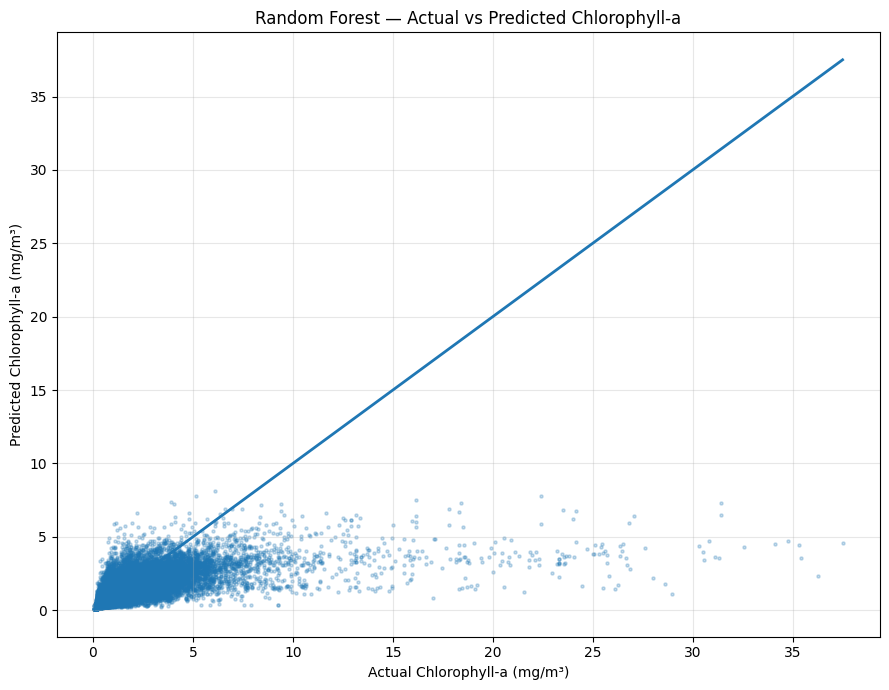

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_actual_vs_predicted.png

CREATING RESIDUAL DISTRIBUTION


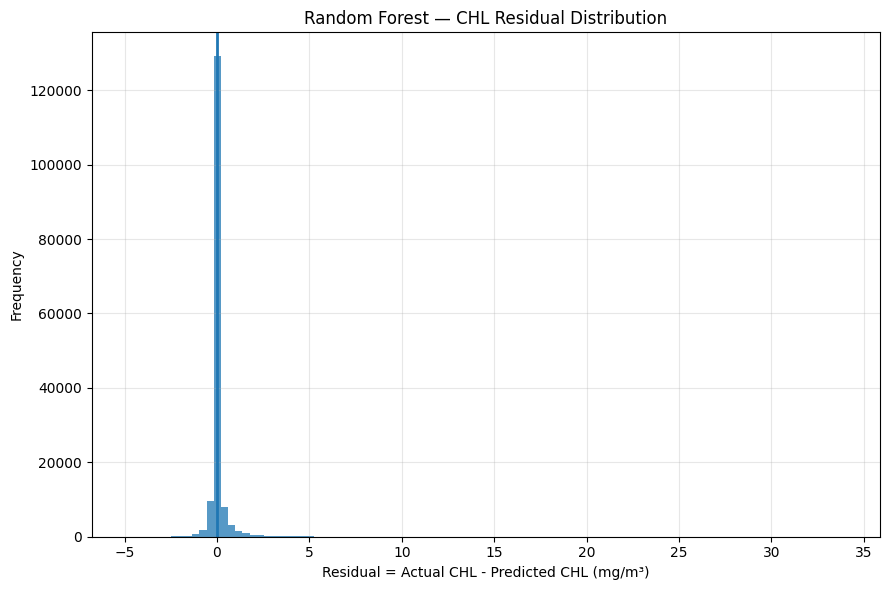

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_residual_distribution.png

DERIVING CHL PRODUCTIVITY THRESHOLDS
50th percentile: 0.298395 mg/m³
75th percentile: 0.545567 mg/m³
90th percentile: 0.922410 mg/m³
95th percentile: 1.304732 mg/m³
99th percentile: 3.127116 mg/m³

Primary high-productivity threshold: 0.545567 mg/m³

HIGH-CHL EVENT DETECTION

75th percentile threshold = 0.545567 mg/m³
Actual events    : 47,730
Predicted events : 50,547
Accuracy          : 0.9437
Precision         : 0.8841
Detection/Recall  : 0.9363
F1-score          : 0.9095
Specificity       : 0.9468
False alarm rate  : 0.0532

90th percentile threshold = 0.922410 mg/m³
Actual events    : 31,000
Predicted events : 31,517
Accuracy          : 0.9509
Precision         : 0.8688
Detection/Recall  : 0.8833
F1-score          : 0.8760
Specificity       : 0.9674
False alarm rate  : 0.0326

95th percentile threshold = 1.304732 mg/m³
Actual events    : 20,587
Pr

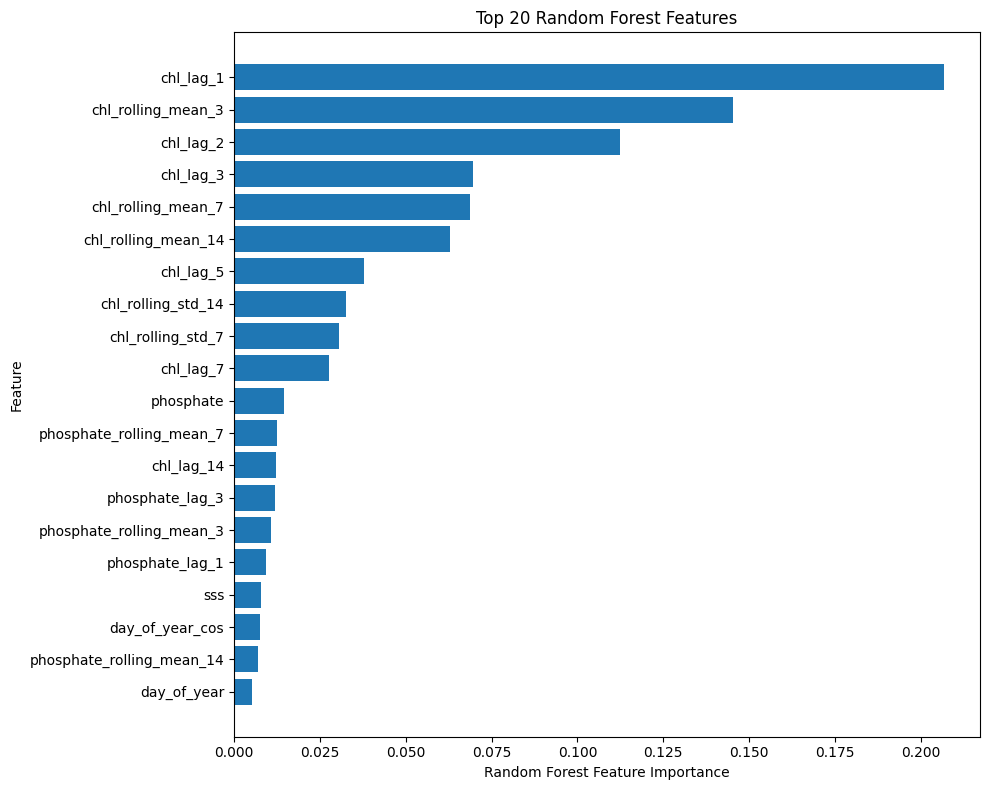

Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_top20_feature_importance.png

SAVING COMPLETE VALIDATION PREDICTIONS
Saved:
/content/drive/MyDrive/Indhi_Marine_Research_Data/06_models/01_Random_Forest/evaluation/random_forest_validation_predictions_with_diagnostics.csv

STEP 31.9P-12B COMPLETE

OVERALL PERFORMANCE
MAE  : 0.196703 mg/m³
RMSE : 0.817120 mg/m³
R²   : 0.524387
Bias : -0.074536 mg/m³

HIGH-CHL EVENT PERFORMANCE
 percentile  threshold_mg_m3  precision  recall_detection_rate  f1_score  false_alarm_rate
         75         0.545567   0.884147               0.936329  0.909491          0.053156
         90         0.922410   0.868769               0.883258  0.875954          0.032594
         95         1.304732   0.825260               0.794433  0.809553          0.025220
         99         3.127116   0.738600               0.264977  0.390029          0.002650

SPATIAL LOCATIONS EVALUATED:
102

FEATURES EVALUATED:
69

In [12]:
# ======================================================================
# STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from scipy.stats import pearsonr, spearmanr

print("=" * 70)
print("STEP 31.9P-12B — COMPREHENSIVE RANDOM FOREST VALIDATION EVALUATION")
print("=" * 70)

# ======================================================================
# 1. PATHS
# ======================================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Indhi_Marine_Research_Data"
)

PREPROCESS_DIR = BASE_DIR / "05_model_preprocessing"

MODEL_DIR = (
    BASE_DIR /
    "06_models" /
    "01_Random_Forest"
)

PREDICTION_FILE = (
    MODEL_DIR /
    "random_forest_validation_predictions.csv"
)

MODEL_FILE = (
    MODEL_DIR /
    "random_forest_chlorophyll_model.joblib"
)

FEATURE_FILE = (
    PREPROCESS_DIR /
    "final_model_feature_columns.csv"
)

OUTPUT_DIR = MODEL_DIR / "evaluation"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nOutput directory:")
print(OUTPUT_DIR)

# ======================================================================
# 2. LOAD VALIDATION PREDICTIONS
# ======================================================================

print("\n" + "=" * 70)
print("LOADING VALIDATION PREDICTIONS")
print("=" * 70)

pred_df = pd.read_csv(
    PREDICTION_FILE,
    parse_dates=["date"]
)

print("\nShape:")
print(pred_df.shape)

print("\nColumns:")
for column in pred_df.columns:
    print("✓", column)

# ======================================================================
# 3. BASIC INTEGRITY CHECK
# ======================================================================

print("\n" + "=" * 70)
print("VALIDATION PREDICTION INTEGRITY CHECK")
print("=" * 70)

required_columns = [
    "date",
    "latitude",
    "longitude",
    "actual_chlorophyll_a",
    "actual_chlorophyll_a_log1p",
    "predicted_chlorophyll_a_log1p",
    "predicted_chlorophyll_a",
]

missing_columns = [
    column
    for column in required_columns
    if column not in pred_df.columns
]

assert len(missing_columns) == 0, (
    f"Missing columns: {missing_columns}"
)

print("✓ All required prediction columns are present.")

print("\nMissing values:")

print(
    pred_df[
        required_columns
    ].isna().sum()
)

assert (
    pred_df[
        required_columns
    ].isna().sum().sum()
    == 0
)

print("\n✓ No missing values.")

# ======================================================================
# 4. EXTRACT TARGETS AND PREDICTIONS
# ======================================================================

actual_log = (
    pred_df["actual_chlorophyll_a_log1p"]
    .to_numpy()
)

predicted_log = (
    pred_df["predicted_chlorophyll_a_log1p"]
    .to_numpy()
)

actual_chl = (
    pred_df["actual_chlorophyll_a"]
    .to_numpy()
)

predicted_chl = (
    pred_df["predicted_chlorophyll_a"]
    .to_numpy()
)

# ======================================================================
# 5. RESIDUALS
# ======================================================================

pred_df["residual_log"] = (
    actual_log - predicted_log
)

pred_df["absolute_error_log"] = (
    np.abs(pred_df["residual_log"])
)

pred_df["squared_error_log"] = (
    pred_df["residual_log"] ** 2
)

pred_df["residual_chl"] = (
    actual_chl - predicted_chl
)

pred_df["absolute_error_chl"] = (
    np.abs(pred_df["residual_chl"])
)

pred_df["squared_error_chl"] = (
    pred_df["residual_chl"] ** 2
)

# ======================================================================
# 6. CONTINUOUS REGRESSION METRICS — LOG SCALE
# ======================================================================

print("\n" + "=" * 70)
print("REGRESSION PERFORMANCE — LOG1P CHL SCALE")
print("=" * 70)

mae_log = mean_absolute_error(
    actual_log,
    predicted_log
)

rmse_log = np.sqrt(
    mean_squared_error(
        actual_log,
        predicted_log
    )
)

r2_log = r2_score(
    actual_log,
    predicted_log
)

median_ae_log = median_absolute_error(
    actual_log,
    predicted_log
)

explained_variance_log = explained_variance_score(
    actual_log,
    predicted_log
)

pearson_log, pearson_log_p = pearsonr(
    actual_log,
    predicted_log
)

spearman_log, spearman_log_p = spearmanr(
    actual_log,
    predicted_log
)

bias_log = np.mean(
    predicted_log - actual_log
)

print(f"MAE                  : {mae_log:.6f}")
print(f"RMSE                 : {rmse_log:.6f}")
print(f"R²                   : {r2_log:.6f}")
print(f"Median Absolute Error: {median_ae_log:.6f}")
print(f"Explained Variance   : {explained_variance_log:.6f}")
print(f"Pearson r            : {pearson_log:.6f}")
print(f"Spearman r           : {spearman_log:.6f}")
print(f"Mean Prediction Bias : {bias_log:.6f}")

# ======================================================================
# 7. CONTINUOUS REGRESSION METRICS — ORIGINAL CHL SCALE
# ======================================================================

print("\n" + "=" * 70)
print("REGRESSION PERFORMANCE — ORIGINAL CHL SCALE")
print("=" * 70)

mae_chl = mean_absolute_error(
    actual_chl,
    predicted_chl
)

rmse_chl = np.sqrt(
    mean_squared_error(
        actual_chl,
        predicted_chl
    )
)

r2_chl = r2_score(
    actual_chl,
    predicted_chl
)

median_ae_chl = median_absolute_error(
    actual_chl,
    predicted_chl
)

explained_variance_chl = explained_variance_score(
    actual_chl,
    predicted_chl
)

pearson_chl, pearson_chl_p = pearsonr(
    actual_chl,
    predicted_chl
)

spearman_chl, spearman_chl_p = spearmanr(
    actual_chl,
    predicted_chl
)

bias_chl = np.mean(
    predicted_chl - actual_chl
)

mean_absolute_percentage_error_chl = (
    np.mean(
        np.abs(
            (actual_chl - predicted_chl)
            /
            np.maximum(
                np.abs(actual_chl),
                1e-8
            )
        )
    )
    * 100
)

print(f"MAE                  : {mae_chl:.6f} mg/m³")
print(f"RMSE                 : {rmse_chl:.6f} mg/m³")
print(f"R²                   : {r2_chl:.6f}")
print(f"Median Absolute Error: {median_ae_chl:.6f} mg/m³")
print(f"Explained Variance   : {explained_variance_chl:.6f}")
print(f"Pearson r            : {pearson_chl:.6f}")
print(f"Spearman r           : {spearman_chl:.6f}")
print(f"Mean Prediction Bias : {bias_chl:.6f} mg/m³")
print(
    f"MAPE                 : "
    f"{mean_absolute_percentage_error_chl:.2f}%"
)

# ======================================================================
# 8. PREDICTION RANGE CHECK
# ======================================================================

print("\n" + "=" * 70)
print("PREDICTION RANGE CHECK")
print("=" * 70)

print(
    f"Actual CHL minimum     : "
    f"{actual_chl.min():.6f}"
)

print(
    f"Actual CHL maximum     : "
    f"{actual_chl.max():.6f}"
)

print(
    f"Predicted CHL minimum  : "
    f"{predicted_chl.min():.6f}"
)

print(
    f"Predicted CHL maximum  : "
    f"{predicted_chl.max():.6f}"
)

# ======================================================================
# 9. OVERALL REGRESSION METRICS TABLE
# ======================================================================

metrics_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "evaluation_split": "Validation",
        "MAE_log1p": mae_log,
        "RMSE_log1p": rmse_log,
        "R2_log1p": r2_log,
        "MedianAE_log1p": median_ae_log,
        "ExplainedVariance_log1p": explained_variance_log,
        "Pearson_r_log1p": pearson_log,
        "Spearman_r_log1p": spearman_log,
        "Bias_log1p": bias_log,
        "MAE_CHL_mg_m3": mae_chl,
        "RMSE_CHL_mg_m3": rmse_chl,
        "R2_CHL": r2_chl,
        "MedianAE_CHL_mg_m3": median_ae_chl,
        "ExplainedVariance_CHL": explained_variance_chl,
        "Pearson_r_CHL": pearson_chl,
        "Spearman_r_CHL": spearman_chl,
        "Bias_CHL_mg_m3": bias_chl,
        "MAPE_CHL_percent": mean_absolute_percentage_error_chl,
    }
])

METRICS_FILE = (
    OUTPUT_DIR /
    "random_forest_validation_regression_metrics.csv"
)

metrics_df.to_csv(
    METRICS_FILE,
    index=False
)

print("\nMetrics saved:")
print(METRICS_FILE)

# ======================================================================
# 10. ACTUAL VS PREDICTED SCATTER
# ======================================================================

print("\n" + "=" * 70)
print("CREATING ACTUAL VS PREDICTED PLOT")
print("=" * 70)

plt.figure(figsize=(9, 7))

plt.scatter(
    actual_chl,
    predicted_chl,
    s=5,
    alpha=0.25
)

min_value = min(
    actual_chl.min(),
    predicted_chl.min()
)

max_value = max(
    actual_chl.max(),
    predicted_chl.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2
)

plt.xlabel(
    "Actual Chlorophyll-a (mg/m³)"
)

plt.ylabel(
    "Predicted Chlorophyll-a (mg/m³)"
)

plt.title(
    "Random Forest — Actual vs Predicted Chlorophyll-a"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

SCATTER_FILE = (
    OUTPUT_DIR /
    "random_forest_actual_vs_predicted.png"
)

plt.savefig(
    SCATTER_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(SCATTER_FILE)

# ======================================================================
# 11. RESIDUAL DISTRIBUTION
# ======================================================================

print("\n" + "=" * 70)
print("CREATING RESIDUAL DISTRIBUTION")
print("=" * 70)

plt.figure(figsize=(9, 6))

plt.hist(
    pred_df["residual_chl"],
    bins=100,
    alpha=0.75
)

plt.axvline(
    0,
    linewidth=2
)

plt.xlabel(
    "Residual = Actual CHL - Predicted CHL (mg/m³)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Random Forest — CHL Residual Distribution"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

RESIDUAL_FILE = (
    OUTPUT_DIR /
    "random_forest_residual_distribution.png"
)

plt.savefig(
    RESIDUAL_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(RESIDUAL_FILE)

# ======================================================================
# 12. RESIDUAL STATISTICS
# ======================================================================

residual_summary = pd.DataFrame([
    {
        "mean_residual": pred_df["residual_chl"].mean(),
        "median_residual": pred_df["residual_chl"].median(),
        "std_residual": pred_df["residual_chl"].std(),
        "minimum_residual": pred_df["residual_chl"].min(),
        "maximum_residual": pred_df["residual_chl"].max(),
        "mean_absolute_residual": pred_df["absolute_error_chl"].mean(),
        "residual_below_zero_count": (
            (pred_df["residual_chl"] < 0).sum()
        ),
        "residual_above_zero_count": (
            (pred_df["residual_chl"] > 0).sum()
        )
    }
])

RESIDUAL_SUMMARY_FILE = (
    OUTPUT_DIR /
    "random_forest_residual_summary.csv"
)

residual_summary.to_csv(
    RESIDUAL_SUMMARY_FILE,
    index=False
)

# ======================================================================
# 13. TRAINING-DERIVED CHL THRESHOLDS
# ======================================================================

print("\n" + "=" * 70)
print("DERIVING CHL PRODUCTIVITY THRESHOLDS")
print("=" * 70)

# IMPORTANT:
# Thresholds are calculated from TRAINING CHL only.
# Validation data is NOT used to define the thresholds.

TRAIN_FILE = (
    PREPROCESS_DIR /
    "final_model_ready_train.csv"
)

train_for_thresholds = pd.read_csv(
    TRAIN_FILE,
    usecols=["chlorophyll_a"]
)

training_chl = (
    train_for_thresholds["chlorophyll_a"]
    .dropna()
)

threshold_percentiles = [
    50,
    75,
    90,
    95,
    99
]

threshold_values = {
    percentile: np.percentile(
        training_chl,
        percentile
    )
    for percentile in threshold_percentiles
}

for percentile, value in threshold_values.items():
    print(
        f"{percentile}th percentile: "
        f"{value:.6f} mg/m³"
    )

# We will use 75th percentile as the preliminary
# high-productivity threshold for event analysis.
#
# IMPORTANT:
# This is a deliberately explicit threshold choice.
# We will also evaluate 90th/95th/99th percentile events.

HIGH_THRESHOLD = threshold_values[75]

print(
    f"\nPrimary high-productivity threshold: "
    f"{HIGH_THRESHOLD:.6f} mg/m³"
)

# ======================================================================
# 14. HIGH-CHL EVENT EVALUATION
# ======================================================================

print("\n" + "=" * 70)
print("HIGH-CHL EVENT DETECTION")
print("=" * 70)

event_results = []

event_percentiles = [
    75,
    90,
    95,
    99
]

for percentile in event_percentiles:

    threshold = threshold_values.get(
        percentile,
        np.percentile(
            training_chl,
            percentile
        )
    )

    actual_event = (
        actual_chl >= threshold
    )

    predicted_event = (
        predicted_chl >= threshold
    )

    accuracy = accuracy_score(
        actual_event,
        predicted_event
    )

    precision = precision_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    recall = recall_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    f1 = f1_score(
        actual_event,
        predicted_event,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        actual_event,
        predicted_event,
        labels=[False, True]
    ).ravel()

    detection_rate = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    false_alarm_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    event_prevalence = (
        actual_event.mean()
    )

    event_results.append({
        "percentile": percentile,
        "threshold_mg_m3": threshold,
        "actual_event_count": int(actual_event.sum()),
        "predicted_event_count": int(predicted_event.sum()),
        "event_prevalence": event_prevalence,
        "accuracy": accuracy,
        "precision": precision,
        "recall_detection_rate": detection_rate,
        "f1_score": f1,
        "specificity": specificity,
        "false_alarm_rate": false_alarm_rate,
        "true_positive": int(tp),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn)
    })

    print(
        f"\n{percentile}th percentile "
        f"threshold = {threshold:.6f} mg/m³"
    )

    print(
        f"Actual events    : {actual_event.sum():,}"
    )

    print(
        f"Predicted events : {predicted_event.sum():,}"
    )

    print(
        f"Accuracy          : {accuracy:.4f}"
    )

    print(
        f"Precision         : {precision:.4f}"
    )

    print(
        f"Detection/Recall  : {detection_rate:.4f}"
    )

    print(
        f"F1-score          : {f1:.4f}"
    )

    print(
        f"Specificity       : {specificity:.4f}"
    )

    print(
        f"False alarm rate  : {false_alarm_rate:.4f}"
    )

event_metrics_df = pd.DataFrame(
    event_results
)

EVENT_METRICS_FILE = (
    OUTPUT_DIR /
    "random_forest_high_chl_event_metrics.csv"
)

event_metrics_df.to_csv(
    EVENT_METRICS_FILE,
    index=False
)

print("\nHigh-CHL event metrics saved:")
print(EVENT_METRICS_FILE)

# ======================================================================
# 15. CONFUSION MATRICES FOR HIGH-CHL EVENTS
# ======================================================================

print("\n" + "=" * 70)
print("HIGH-CHL CONFUSION MATRICES")
print("=" * 70)

for percentile in event_percentiles:

    threshold = threshold_values[
        percentile
    ]

    actual_event = (
        actual_chl >= threshold
    )

    predicted_event = (
        predicted_chl >= threshold
    )

    cm = confusion_matrix(
        actual_event,
        predicted_event,
        labels=[False, True]
    )

    print(
        f"\n{percentile}th percentile "
        f"threshold = {threshold:.6f}"
    )

    print(
        "Rows = Actual [Not High, High]"
    )

    print(
        "Columns = Predicted [Not High, High]"
    )

    print(cm)

# ======================================================================
# 16. MONTHLY PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("MONTHLY PERFORMANCE")
print("=" * 70)

pred_df["year"] = (
    pred_df["date"].dt.year
)

pred_df["month"] = (
    pred_df["date"].dt.month
)

pred_df["month_name"] = (
    pred_df["date"].dt.month_name()
)

monthly_results = []

for month in sorted(
    pred_df["month"].unique()
):

    subset = pred_df[
        pred_df["month"] == month
    ]

    if len(subset) < 2:
        continue

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    monthly_results.append({
        "month": month,
        "month_name": subset[
            "month_name"
        ].iloc[0],
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": r2_score(
            actual,
            predicted
        ),
        "bias": np.mean(
            predicted - actual
        )
    })

monthly_df = pd.DataFrame(
    monthly_results
)

MONTHLY_FILE = (
    OUTPUT_DIR /
    "random_forest_monthly_performance.csv"
)

monthly_df.to_csv(
    MONTHLY_FILE,
    index=False
)

print(monthly_df.to_string(index=False))

# ======================================================================
# 17. YEARLY PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("YEARLY PERFORMANCE")
print("=" * 70)

yearly_results = []

for year in sorted(
    pred_df["year"].unique()
):

    subset = pred_df[
        pred_df["year"] == year
    ]

    if len(subset) < 2:
        continue

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    yearly_results.append({
        "year": year,
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": r2_score(
            actual,
            predicted
        ),
        "bias": np.mean(
            predicted - actual
        )
    })

yearly_df = pd.DataFrame(
    yearly_results
)

YEARLY_FILE = (
    OUTPUT_DIR /
    "random_forest_yearly_performance.csv"
)

yearly_df.to_csv(
    YEARLY_FILE,
    index=False
)

print(yearly_df.to_string(index=False))

# ======================================================================
# 18. SPATIAL PERFORMANCE
# ======================================================================

print("\n" + "=" * 70)
print("SPATIAL PERFORMANCE — 102 LOCATIONS")
print("=" * 70)

spatial_results = []

for (
    latitude,
    longitude
), subset in pred_df.groupby(
    ["latitude", "longitude"]
):

    actual = subset[
        "actual_chlorophyll_a"
    ]

    predicted = subset[
        "predicted_chlorophyll_a"
    ]

    spatial_results.append({
        "latitude": latitude,
        "longitude": longitude,
        "observations": len(subset),
        "MAE": mean_absolute_error(
            actual,
            predicted
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        ),
        "R2": (
            r2_score(
                actual,
                predicted
            )
            if actual.nunique() > 1
            else np.nan
        ),
        "bias": np.mean(
            predicted - actual
        ),
        "actual_mean_CHL": actual.mean(),
        "predicted_mean_CHL": predicted.mean(),
        "actual_max_CHL": actual.max(),
        "predicted_max_CHL": predicted.max()
    })

spatial_df = pd.DataFrame(
    spatial_results
)

SPATIAL_FILE = (
    OUTPUT_DIR /
    "random_forest_spatial_performance.csv"
)

spatial_df.to_csv(
    SPATIAL_FILE,
    index=False
)

print(
    f"Locations evaluated: "
    f"{len(spatial_df)}"
)

print("\nBest 10 locations by RMSE:")

print(
    spatial_df.sort_values(
        "RMSE"
    ).head(10).to_string(
        index=False
    )
)

print("\nWorst 10 locations by RMSE:")

print(
    spatial_df.sort_values(
        "RMSE",
        ascending=False
    ).head(10).to_string(
        index=False
    )
)

# ======================================================================
# 19. FEATURE IMPORTANCE
# ======================================================================

print("\n" + "=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

import joblib

rf_model = joblib.load(
    MODEL_FILE
)

feature_importances = (
    rf_model.feature_importances_
)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": feature_importances
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["rank"] = (
    np.arange(
        1,
        len(importance_df) + 1
    )
)

IMPORTANCE_FILE = (
    OUTPUT_DIR /
    "random_forest_feature_importance.csv"
)

importance_df.to_csv(
    IMPORTANCE_FILE,
    index=False
)

print(
    importance_df.head(30).to_string(
        index=False
    )
)

print("\nFeature importance saved:")
print(IMPORTANCE_FILE)

# ======================================================================
# 20. FEATURE IMPORTANCE PLOT
# ======================================================================

top_n = 20

top_features = (
    importance_df
    .head(top_n)
    .sort_values(
        "importance"
    )
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel(
    "Random Forest Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.tight_layout()

IMPORTANCE_PLOT = (
    OUTPUT_DIR /
    "random_forest_top20_feature_importance.png"
)

plt.savefig(
    IMPORTANCE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(IMPORTANCE_PLOT)

# ======================================================================
# 21. SAVE COMPLETE VALIDATION RESULTS
# ======================================================================

print("\n" + "=" * 70)
print("SAVING COMPLETE VALIDATION PREDICTIONS")
print("=" * 70)

COMPLETE_PREDICTIONS_FILE = (
    OUTPUT_DIR /
    "random_forest_validation_predictions_with_diagnostics.csv"
)

pred_df.to_csv(
    COMPLETE_PREDICTIONS_FILE,
    index=False
)

print(
    "Saved:"
)

print(
    COMPLETE_PREDICTIONS_FILE
)

# ======================================================================
# 22. FINAL SUMMARY
# ======================================================================

print("\n" + "=" * 70)
print("STEP 31.9P-12B COMPLETE")
print("=" * 70)

print("\nOVERALL PERFORMANCE")
print(
    f"MAE  : {mae_chl:.6f} mg/m³"
)

print(
    f"RMSE : {rmse_chl:.6f} mg/m³"
)

print(
    f"R²   : {r2_chl:.6f}"
)

print(
    f"Bias : {bias_chl:.6f} mg/m³"
)

print("\nHIGH-CHL EVENT PERFORMANCE")
print(
    event_metrics_df[
        [
            "percentile",
            "threshold_mg_m3",
            "precision",
            "recall_detection_rate",
            "f1_score",
            "false_alarm_rate"
        ]
    ].to_string(index=False)
)

print("\nSPATIAL LOCATIONS EVALUATED:")
print(
    len(spatial_df)
)

print("\nFEATURES EVALUATED:")
print(
    len(importance_df)
)

print("\nTEST DATA:")
print("NOT USED")

print("\nAll evaluation outputs saved to:")
print(OUTPUT_DIR)

print("\nNext:")
print("STEP 31.9P-12C — RANDOM FOREST TEMPORAL/EXTREME/SPATIAL VISUAL ANALYSIS")